# Hallazgos de CLOD por clase (train, k-fold)

Cuántos hallazgos de cada tipo deja CLOD (`src/find_issues.py`) en cada clase y en cada especie,
sobre las predicciones fuera de muestra del k-fold de `yolo26s_v3`: cada ventana de train la
predice el modelo del pliegue que no la vio.

- `missing`: el modelo ve con confianza una llamada donde no hay anotación; cuenta en la clase
  del modelo (`predicted`).
- `spurious`: ninguna predicción de ninguna clase toca la anotación.
- `location`: su clase la ve, pero la caja no calza (IoU < 0,6).
- `label`: su clase no la ve y otra sí, con confianza.

Los tres últimos cuentan en la clase de la anotación (`annotated`).

Las tasas son por cada 100 anotaciones únicas de la clase en train (sin las filas en revisión),
no por ventana: una anotación aparece en dos o tres ventanas solapadas y los hallazgos ya vienen
fundidos entre ellas. Las clases *de ventana* (`*`), cuya caja ocupa el clip entero, van en gris:
sus hallazgos no se leen como los de una detección.

Lee `runs/yolo26s_v3_kfold5/hallazgos_train.csv` y su volcado; escribe
`runs/yolo26s_v3_kfold5/hallazgos_por_clase.csv`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from analysis.review import load_annotations, relative
from core.config import RUNS_DIR
from data import cache
from data.species import split_label
from evaluation.evaluator import RawPredictions, path_for
from evaluation.metrics import window_classes

RUN = "yolo26s_v3_kfold5"
FINDINGS = RUNS_DIR / RUN / "hallazgos_train.csv"
OUTPUT = RUNS_DIR / RUN / "hallazgos_por_clase.csv"
TYPES = ["missing", "spurious", "location", "label"]

# Colores: una serie por panel, gris para lo que no se compara
BAR, MUTED, BAND = "#2a78d6", "#c3c2b7", "#f0efec"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e1e0d9"
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK_2,
        "xtick.color": INK_2,
        "ytick.color": INK,
        "font.size": 10,
    }
)
pd.set_option("display.width", 180)

## Por clase

`missing_sin_fila` son los `missing` sin nada anotado debajo (`existing_annotation = none`): las
omisiones de anotación candidatas. El resto cae sobre una anotación que ya existe: del conjunto
pero con otra caja o clase, apartada para revisión, o de una clase que el modelo no aprende.

In [2]:
dump = RawPredictions.load(path_for(RUNS_DIR / RUN, RUN, cache.TRAIN))
names = dump.labels
window = {names[c] for c in window_classes(dump.truth, len(names))}
train_recordings = {relative(r) for r in dump.recording_names}

annotations = load_annotations(cache.meta()["joined_labels"])
reference = annotations[
    annotations.recording.isin(train_recordings)
    & ~annotations.requires_review
    & annotations.label.isin(names)
]

findings = pd.read_csv(FINDINGS)
# La clase de cada hallazgo: la del modelo en `missing`, la de la anotación en los demás
findings["clase"] = findings.predicted.where(findings.issue == "missing", findings.annotated)
counts = (
    findings.groupby(["clase", "issue"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=names, columns=TYPES, fill_value=0)
)
no_row = findings[(findings.issue == "missing") & (findings.existing_annotation == "none")]

per_class = pd.DataFrame(
    {
        "especie": [split_label(n)[0] for n in names],
        "clase": names,
        "de_ventana": [n in window for n in names],
        "anotaciones": reference.label.value_counts().reindex(names, fill_value=0).to_numpy(),
    }
)
for kind in TYPES:
    per_class[kind] = counts[kind].to_numpy()
per_class["missing_sin_fila"] = no_row.clase.value_counts().reindex(names, fill_value=0).to_numpy()
per_class["total"] = per_class[TYPES].sum(axis=1)
for kind in [*TYPES, "total"]:
    per_class[f"{kind}_por_100"] = (100 * per_class[kind] / per_class.anotaciones).round(1)
per_class.to_csv(OUTPUT, index=False)
print(
    f"{len(findings)} hallazgos, {len(reference)} anotaciones únicas en train -> {OUTPUT.relative_to(ROOT)}"
)
per_class

5933 hallazgos, 10283 anotaciones únicas en train -> runs/yolo26s_v3_kfold5/hallazgos_por_clase.csv


,especie,clase,de_ventana,anotaciones,missing,spurious,location,label,missing_sin_fila,total,missing_por_100,spurious_por_100,location_por_100,label_por_100,total_por_100
0,aa,aa/gc,False,471,54,151,15,1,52,221,11.5,32.1,3.2,0.2,46.9
1,aa,aa/hm,False,78,5,3,3,0,5,11,6.4,3.8,3.8,0.0,14.1
2,aa,aa/sc,False,95,6,17,5,1,6,29,6.3,17.9,5.3,1.1,30.5
3,ac,ac/bc,False,1464,141,257,225,9,84,632,9.6,17.6,15.4,0.6,43.2
4,ac,ac/chc,False,134,47,43,16,25,45,131,35.1,32.1,11.9,18.7,97.8
5,ac,ac/gc,False,81,57,59,19,11,52,146,70.4,72.8,23.5,13.6,180.2
6,ac,ac/sc,False,97,25,21,16,10,19,72,25.8,21.6,16.5,10.3,74.2
7,as,as/bc,False,1135,154,268,115,5,119,542,13.6,23.6,10.1,0.4,47.8
8,as,as/hc,True,716,170,146,155,3,140,474,23.7,20.4,21.6,0.4,66.2
9,lw,lw/cs,False,1365,108,115,67,0,88,290,7.9,8.4,4.9,0.0,21.2


## Por clase, en una figura

Un panel por tipo, con la misma escala en los cuatro: el largo de la barra es el número de
hallazgos por cada 100 anotaciones de la clase, y el número al final de las tres más altas de
cada panel, también. Las clases van agrupadas por especie, en bandas.

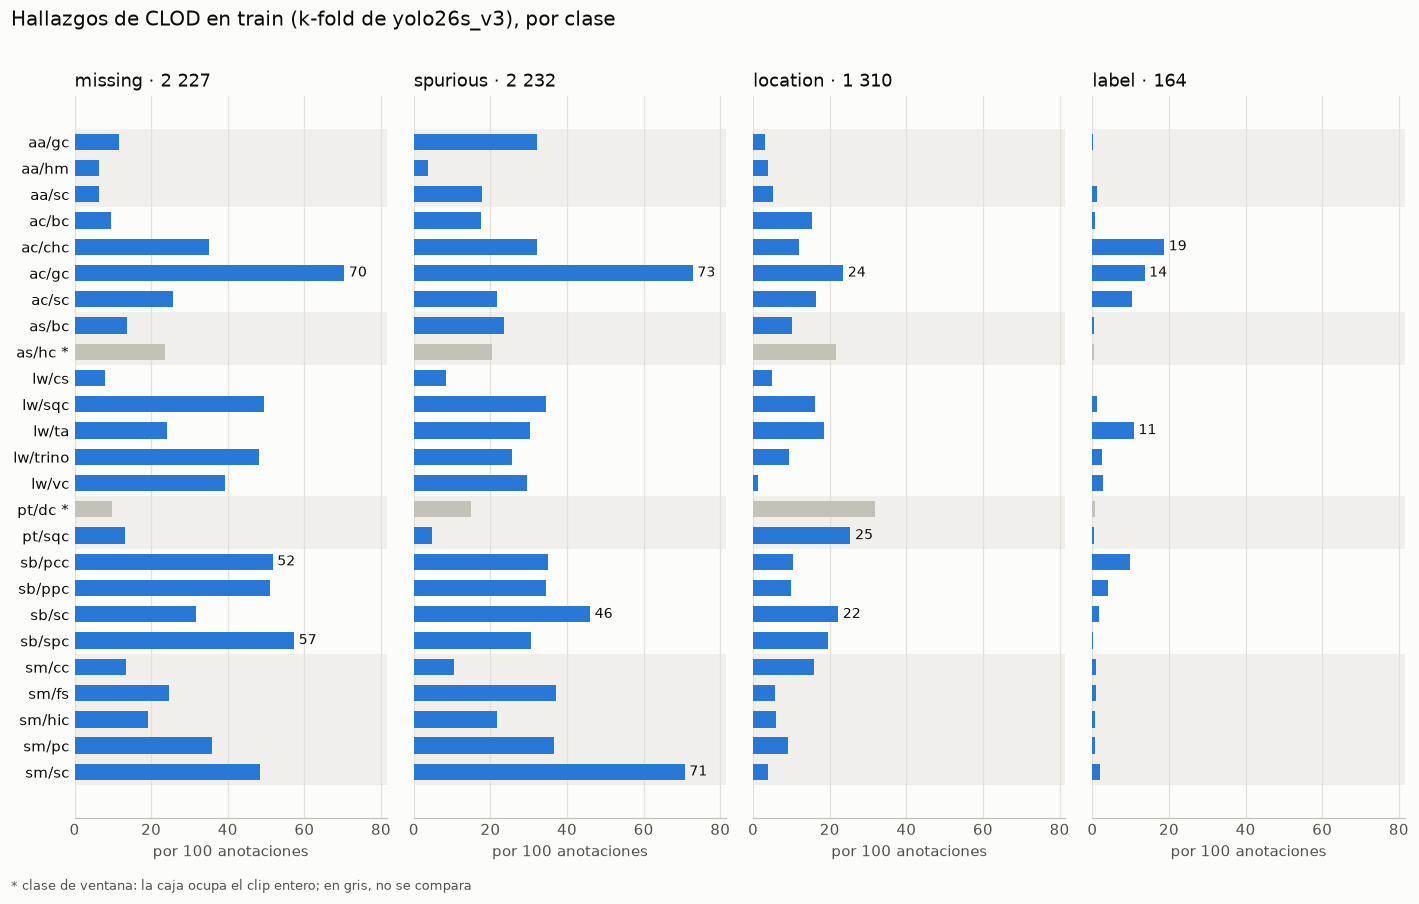

In [3]:
fig, axes = plt.subplots(1, len(TYPES), figsize=(13, 8.2), sharey=True, sharex=True)
rows = range(len(per_class))
species = per_class.especie.to_numpy()
starts = [i for i in rows if i == 0 or species[i] != species[i - 1]]
x_max = per_class[[f"{k}_por_100" for k in TYPES]].to_numpy().max() * 1.12

for ax, kind in zip(axes, TYPES, strict=True):
    values = per_class[f"{kind}_por_100"].to_numpy()
    colors = [MUTED if w else BAR for w in per_class.de_ventana]
    for n, start in enumerate(starts):  # banda por especie, alternada
        end = starts[n + 1] if n + 1 < len(starts) else len(per_class)
        if n % 2 == 0:
            ax.axhspan(start - 0.5, end - 0.5, color=BAND, zorder=0, lw=0)
    ax.barh(list(rows), values, height=0.62, color=colors, zorder=2)
    comparable = per_class[~per_class.de_ventana]
    for i in comparable[f"{kind}_por_100"].nlargest(3).index:
        ax.text(
            values[i] + x_max * 0.015, i, f"{values[i]:.0f}", va="center", fontsize=9, color=INK
        )
    ax.set_title(
        f"{kind} · {int(per_class[kind].sum()):,}".replace(",", " "), loc="left", color=INK
    )
    ax.grid(axis="x", color=GRID, lw=0.8, zorder=1)
    ax.set_xlim(0, x_max)
    ax.tick_params(length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.set_xlabel("por 100 anotaciones")

labels = [f"{c} *" if w else c for c, w in zip(per_class.clase, per_class.de_ventana, strict=True)]
axes[0].set_yticks(list(rows), labels)
axes[0].invert_yaxis()
fig.suptitle(
    "Hallazgos de CLOD en train (k-fold de yolo26s_v3), por clase",
    x=0.01,
    ha="left",
    fontsize=13,
    color=INK,
)
fig.text(
    0.01,
    0.005,
    "* clase de ventana: la caja ocupa el clip entero; en gris, no se compara",
    fontsize=8.5,
    color=INK_2,
)
fig.tight_layout(rect=(0, 0.02, 1, 0.97))
plt.show()

## Por especie

In [4]:
per_species = per_class.groupby("especie")[
    ["anotaciones", *TYPES, "missing_sin_fila", "total"]
].sum()
for kind in [*TYPES, "total"]:
    per_species[f"{kind}_por_100"] = (100 * per_species[kind] / per_species.anotaciones).round(1)
per_species.sort_values("total_por_100", ascending=False)

,anotaciones,missing,spurious,location,label,missing_sin_fila,total,missing_por_100,spurious_por_100,location_por_100,label_por_100,total_por_100
especie,,,,,,,,,,,,
sb,1354,707,457,184,46,678,1394,52.2,33.8,13.6,3.4,103.0
ac,1776,270,380,276,55,200,981,15.2,21.4,15.5,3.1,55.2
as,1851,324,414,270,8,259,1016,17.5,22.4,14.6,0.4,54.9
sm,2024,395,436,244,20,353,1095,19.5,21.5,12.1,1.0,54.1
pt,569,64,61,166,3,53,294,11.2,10.7,29.2,0.5,51.7
lw,2065,402,313,147,30,355,892,19.5,15.2,7.1,1.5,43.2
aa,644,65,171,23,2,63,261,10.1,26.6,3.6,0.3,40.5


## ¿Van juntos `missing` y `spurious`?

Si al modelo se le borra el límite entre evento y fondo en una clase, debería fallar hacia los
dos lados: ver llamadas donde no hay anotación (`missing`) y no ver las que sí la tienen
(`spurious`). Un punto por clase, sin las de ventana. Que vayan juntos no dice por qué: lo mismo
saldría de anotaciones incompletas que enseñan al modelo que ciertas llamadas son fondo, o de
clases difíciles en sí (llamadas débiles, cortas o encuadradas sin criterio fijo). El tamaño de
la clase se descarta abajo.

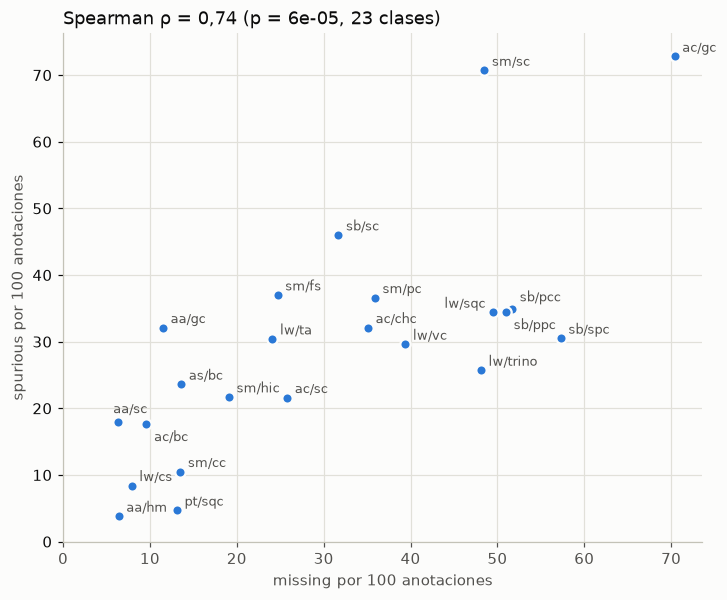

ρ con el número de anotaciones: missing -0.25, spurious -0.30


In [5]:
comparable = per_class[~per_class.de_ventana]
x, y = comparable.missing_por_100, comparable.spurious_por_100
rho, p = spearmanr(x, y)
size_missing, _ = spearmanr(comparable.anotaciones, x)
size_spurious, _ = spearmanr(comparable.anotaciones, y)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(x, y, s=46, color=BAR, edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
# Etiquetas que se pisan con la vecina: (dx, dy) en puntos y alineación
OFFSETS = {
    "lw/sqc": (-5, 3, "right"),
    "sb/pcc": (5, 5, "left"),
    "sb/ppc": (5, -11, "left"),
    "aa/sc": (-3, 6, "left"),
    "ac/bc": (5, -11, "left"),
}
for row in comparable.itertuples():
    name = str(row.clase)
    dx, dy, ha = OFFSETS.get(name, (5, 3, "left"))
    ax.annotate(
        name,
        (row.missing_por_100, row.spurious_por_100),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        fontsize=8.5,
        color=INK_2,
    )
ax.set_xlabel("missing por 100 anotaciones")
ax.set_ylabel("spurious por 100 anotaciones")
ax.set_title(
    f"Spearman ρ = {rho:.2f} (p = {p:.0e}, {len(comparable)} clases)".replace(".", ","),
    loc="left",
    color=INK,
)
ax.grid(color=GRID, lw=0.8, zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.show()
print(f"ρ con el número de anotaciones: missing {size_missing:.2f}, spurious {size_spurious:.2f}")

## Dónde se juntan los `spurious`

Si los `spurious` fueran fallos parejos del modelo, se repartirían entre las grabaciones de la
clase. Las que concentran muchos de una misma clase son las primeras que conviene escuchar: ahí
puede haber un criterio de anotación distinto, o algo en esa grabación que el modelo no ve.

In [6]:
spurious = findings[findings.issue == "spurious"]
by_recording = spurious.groupby(["clase", "folder", "file"]).size().rename("spurious").reset_index()
by_recording["% de la clase"] = (
    100 * by_recording.spurious / by_recording.clase.map(spurious.clase.value_counts())
).round(0)
by_recording.sort_values("spurious", ascending=False).head(10).reset_index(drop=True)

,clase,folder,file,spurious,% de la clase
0,as/bc,howler_monkey__AS,20240405_055925.wav,68,25.0
1,aa/gc,night_monkey__AA,20240117_051649.wav,52,34.0
2,aa/gc,night_monkey__AA,20240117_051057.wav,52,34.0
3,sm/sc,large_headed_capuchin__SM,20240414_065909.wav,33,47.0
4,ac/bc,peruvian_spider_monkey__AC,20240227_102325.wav,32,12.0
5,as/bc,howler_monkey__AS,20240602_081140.wav,25,9.0
6,ac/bc,peruvian_spider_monkey__AC,20240117_060129.wav,21,8.0
7,ac/bc,peruvian_spider_monkey__AC,20240419_055615.wav,19,7.0
8,ac/bc,peruvian_spider_monkey__AC,20241128_060026.wav,16,6.0
9,sb/ppc,bolivian_squirrel_monkey__SB,20240516_082623.wav,15,6.0
